# Exploratory Data Analysis — Multi-View Pig Posture Recognition

Dieses Notebook analysiert den Datensatz systematisch und leitet daraus die **konkreten Designentscheidungen** ab, die in den späteren Trainings-Notebooks umgesetzt wurden.

**Aufbau:**
1. Datensatz-Übersicht — Was enthält jede Spalte?
2. Klassenverteilung — Wie unbalanciert ist der Datensatz?
3. Kamera-Analyse — Welche Kameras gibt es, und welche kommen nur im Test vor?
4. Kamera × Klasse — Welche Klassen werden von welchen Kameras gesehen?
5. BBox-Statistiken — Wie groß sind die Bounding Boxes, wie variabel?
6. Data-Leakage-Risiko — Warum ist ein einfacher `train_test_split` problematisch?
7. Zusammenfassung — Welche Erkenntnis führte zu welcher Notebook-Entscheidung?

## Setup

In [1]:
import os, ast, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image

CLASS_NAMES = {
    0: 'Lateral_lying_left',
    1: 'Lateral_lying_right',
    2: 'Sitting',
    3: 'Standing',
    4: 'Sternal_lying'
}

# Auto-Erkennung des Datenpfads (lokal + Server)
_candidates = [
    r'C:\Users\LampeF\Mittelstufenprojekt\multiview_pig_posture_recognition',
    'multiview_pig_posture_recognition',
    './multiview_pig_posture_recognition',
    '/datasets/multi-view-pig-posture-recognition',
    '/multi-view-pig-posture-recognition',
]
DATA_ROOT = next((p for p in _candidates if os.path.isdir(p)), None)
assert DATA_ROOT is not None, 'Datenpfad nicht gefunden!'
print(f'Datenpfad: {DATA_ROOT}')

df1 = pd.read_csv(os.path.join(DATA_ROOT, 'train1.csv'))
df2 = pd.read_csv(os.path.join(DATA_ROOT, 'train2.csv'))
df_test = pd.read_csv(os.path.join(DATA_ROOT, 'test.csv'))

df1['split'] = 'T1'
df2['split'] = 'T2'
df = pd.concat([df1, df2], ignore_index=True)

# bbox aus String -> Liste
df['bbox_parsed'] = df['bbox'].apply(ast.literal_eval)
df['bbox_cx'] = df['bbox_parsed'].apply(lambda b: b[0])
df['bbox_cy'] = df['bbox_parsed'].apply(lambda b: b[1])
df['bbox_w']  = df['bbox_parsed'].apply(lambda b: b[2])
df['bbox_h']  = df['bbox_parsed'].apply(lambda b: b[3])

# Kamera-ID aus image_id extrahieren: pen1_orb_cam1_<datum>.jpg -> pen1_orb_cam1
def extract_camera(image_id):
    m = re.match(r'(pen\d+_[a-zA-Z0-9]+_cam\d+)', str(image_id))
    return m.group(1) if m else 'unbekannt'

df['camera'] = df['image_id'].apply(extract_camera)
df_test['camera'] = df_test['image_id'].apply(extract_camera)

print(f'Train-Samples gesamt: {len(df):,}  (T1: {len(df1):,} | T2: {len(df2):,})')
print(f'Test-Samples:         {len(df_test):,}')

Datenpfad: C:\Users\LampeF\Mittelstufenprojekt\multiview_pig_posture_recognition


Train-Samples gesamt: 46,384  (T1: 22,934 | T2: 23,450)
Test-Samples:         11,708


## 1. Datensatz-Übersicht

Jede Zeile ist ein einzelnes **Schwein** (Bounding Box + Klasse) in einem Bild. Mehrere Schweine pro Bild sind möglich — dasselbe `image_id` kann also mehrfach vorkommen.

| Spalte | Bedeutung |
|---|---|
| `row_id` | Eindeutige ID pro Schwein-Annotation |
| `image_id` | Dateiname des Originalbilds (enthält Kamera + Zeitstempel) |
| `width` / `height` | Bildgröße in Pixeln |
| `bbox` | Bounding Box als `[center_x, center_y, w, h]` |
| `class_id` | Pose-Klasse (0–4) |

In [2]:
df.head(7)

,row_id,image_id,width,height,bbox,class_id,split,bbox_parsed,bbox_cx,bbox_cy,bbox_w,bbox_h,camera
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0,T1,"[1031.5, 368.0, 349.0, 435.0]",1031.5,368.0,349.0,435.0,pen1_orb_cam1
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4,T1,"[1278.5, 428.0, 233.0, 438.0]",1278.5,428.0,233.0,438.0,pen1_orb_cam1
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1,T1,"[732.0, 137.5, 342.0, 198.0]",732.0,137.5,342.0,198.0,pen1_orb_cam1
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0,169.0,370.0,263.0]",0,T1,"[830.0, 169.0, 370.0, 263.0]",830.0,169.0,370.0,263.0,pen1_orb_cam1
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5,314.8,381.5,386.6]",3,T1,"[611.5, 314.8, 381.5, 386.6]",611.5,314.8,381.5,386.6,pen1_orb_cam1
5,train_pen1_orb_cam1_20250108_085204_0005,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1023.4,261.6,340.6,192.4]",4,T1,"[1023.4, 261.6, 340.6, 192.4]",1023.4,261.6,340.6,192.4,pen1_orb_cam1
6,train_pen1_orb_cam1_20250108_085204_0006,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[662.3,96.2,349.7,183.8]",1,T1,"[662.3, 96.2, 349.7, 183.8]",662.3,96.2,349.7,183.8,pen1_orb_cam1


**Was der Output zeigt:** Die ersten Zeilen stammen alle vom selben `image_id` (`pen1_orb_cam1_...`). Das bedeutet: Ein einzelnes Bild enthält typischerweise **mehrere Schweine gleichzeitig**. Das wird später beim Data-Split wichtig (→ Abschnitt 6).

## 2. Klassenverteilung

Schweine liegen den Großteil des Tages — Stehen und Sitzen sind seltene Ereignisse. Das führt zu einem stark unbalancierten Datensatz.

Klassenverteilung im Trainingsdatensatz (T1 + T2):
  Klasse                     Anzahl   Anteil
  --------------------------------------------
  Lateral_lying_left          6,136    13.2%  █████
  Lateral_lying_right         6,811    14.7%  █████
  Sitting                     1,375     3.0%  █
  Standing                   19,545    42.1%  ████████████████
  Sternal_lying              12,517    27.0%  ██████████

  Imbalance-Faktor (max/min): 14.2×


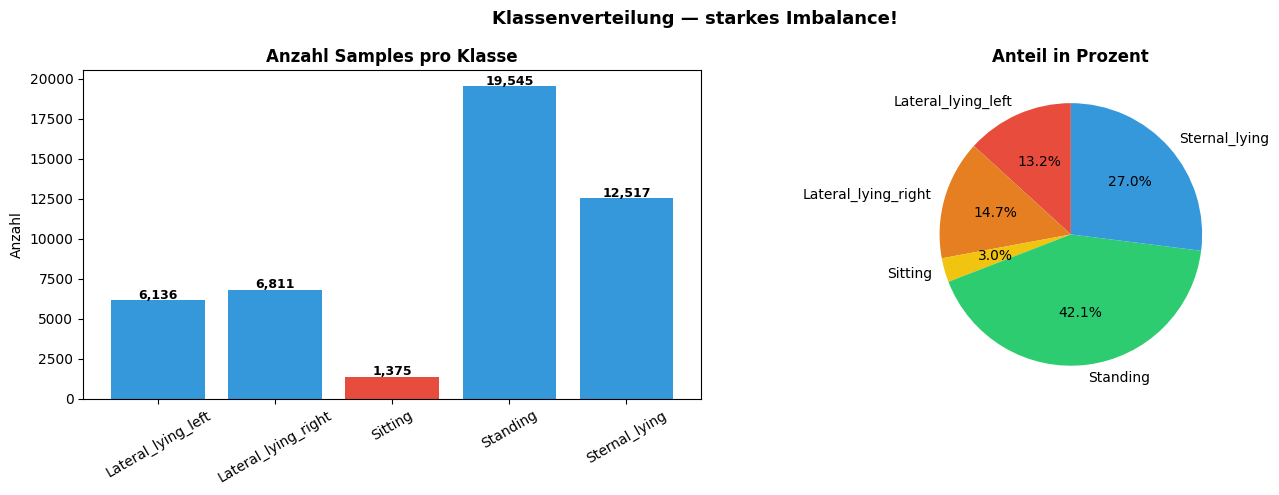

In [3]:
counts = df['class_id'].value_counts().sort_index()
total = len(df)

print('Klassenverteilung im Trainingsdatensatz (T1 + T2):')
print(f'  {"Klasse":<25} {"Anzahl":>7}  {"Anteil":>7}')
print('  ' + '-' * 44)
for cid, n in counts.items():
    bar = '█' * int(n / total * 40)
    print(f'  {CLASS_NAMES[cid]:<25} {n:>7,}  {n/total*100:>6.1f}%  {bar}')
print(f'\n  Imbalance-Faktor (max/min): {counts.max() / counts.min():.1f}×')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c' if cid == counts.idxmin() else '#3498db' for cid in counts.index]
axes[0].bar([CLASS_NAMES[i] for i in counts.index], counts.values, color=colors)
axes[0].set_title('Anzahl Samples pro Klasse', fontweight='bold')
axes[0].set_ylabel('Anzahl')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 80, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

axes[1].pie(counts.values, labels=[CLASS_NAMES[i] for i in counts.index],
            autopct='%1.1f%%', startangle=90,
            colors=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'])
axes[1].set_title('Anteil in Prozent', fontweight='bold')

plt.suptitle('Klassenverteilung — starkes Imbalance!', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Was der Output zeigt:**
- **Sitting (rot)** ist mit ~3% die seltenste Klasse — 14× seltener als Standing.
- Ein Modell, das bei Unsicherheit immer "Standing" rät, hat ~42% Accuracy — aber einen miserablen Macro-F1.

> **→ Erkenntnis:** Ein Standard-`CrossEntropyLoss` ohne Gewichte bevorzugt häufige Klassen. Ab **Notebook 08** (`efficientnet_b4_baseline`) wurden deshalb **Class Weights** verwendet. In **Notebook 24** (`advanced_strategies`) wurde zusätzlich **Focal Loss** getestet, der nicht nur die Klassen-Häufigkeit, sondern auch die Vorhersage-Sicherheit berücksichtigt.

## 3. Kamera-Analyse

Der `image_id`-Name kodiert die Kamera: `pen1_orb_cam1_<datum>.jpg`
- `pen1` / `pen2` = Gehege (Stall-Abteil)
- `orb` / `tur` = Kameratyp (Orbital/Turm — unterschiedliche Höhe und Perspektive!)
- `cam1` / `cam2` = Kameranummer

**Zentrale Frage:** Welche Kameras sind im Training, welche im Test?

Train-Kameras (8):  ['pen1_orb_cam1', 'pen1_orb_cam2', 'pen1_tur_cam1', 'pen1_tur_cam2', 'pen2_orb_cam1', 'pen2_orb_cam2', 'pen2_tur_cam1', 'pen2_tur_cam2']
Test-Kameras  (3):  ['pen1_tur_cam1', 'pen2_orb_cam2', 'pen2_tur_cam2']

Nur im Training     (5): ['pen1_orb_cam1', 'pen1_orb_cam2', 'pen1_tur_cam2', 'pen2_orb_cam1', 'pen2_tur_cam1']
Nur im Test         (0): []
In beiden           (3): ['pen1_tur_cam1', 'pen2_orb_cam2', 'pen2_tur_cam2']


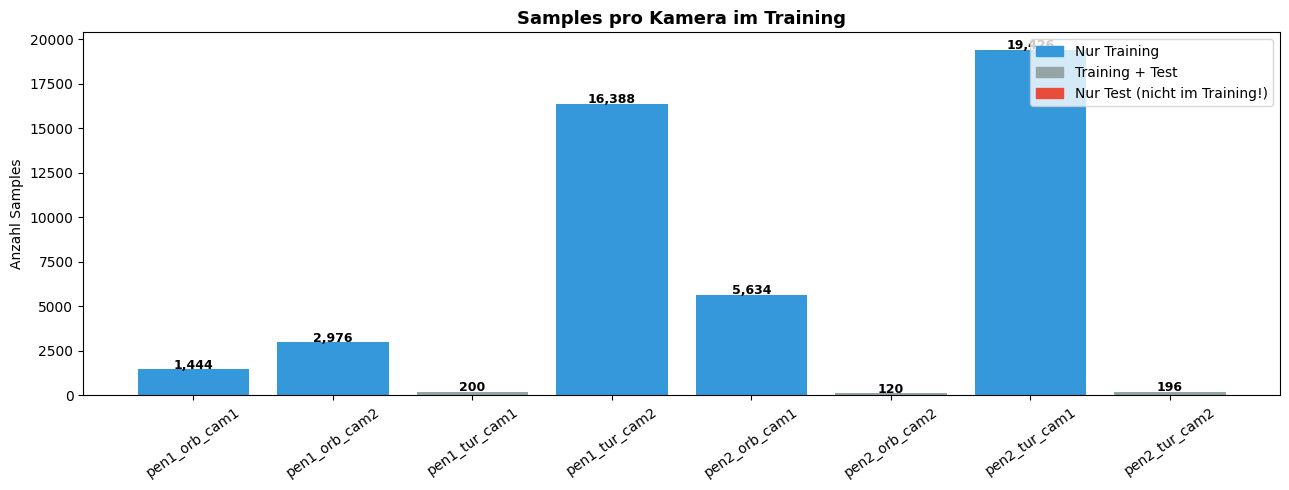

In [4]:
train_cams = set(df['camera'].unique())
test_cams  = set(df_test['camera'].unique())
only_train = train_cams - test_cams
only_test  = test_cams - train_cams
both       = train_cams & test_cams

print(f'Train-Kameras ({len(train_cams)}):  {sorted(train_cams)}')
print(f'Test-Kameras  ({len(test_cams)}):  {sorted(test_cams)}')
print()
print(f'Nur im Training     ({len(only_train)}): {sorted(only_train)}')
print(f'Nur im Test         ({len(only_test)}): {sorted(only_test)}')
print(f'In beiden           ({len(both)}): {sorted(both)}')

cam_counts_train = df['camera'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(13, 5))
bar_colors = ['#e74c3c' if c in only_test else '#95a5a6' if c in both else '#3498db'
              for c in cam_counts_train.index]
bars = ax.bar(cam_counts_train.index, cam_counts_train.values, color=bar_colors)
for bar, v in zip(bars, cam_counts_train.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 30, f'{v:,}',
            ha='center', fontsize=9, fontweight='bold')
ax.set_title('Samples pro Kamera im Training', fontweight='bold', fontsize=13)
ax.set_ylabel('Anzahl Samples')
ax.tick_params(axis='x', rotation=35)

from matplotlib.patches import Patch
legend = [Patch(color='#3498db', label='Nur Training'),
          Patch(color='#95a5a6', label='Training + Test'),
          Patch(color='#e74c3c', label='Nur Test (nicht im Training!)')]
ax.legend(handles=legend, loc='upper right')
plt.tight_layout()
plt.show()

**Was der Output zeigt:**
- **5 Kameras kommen nur im Training vor** (blau), **3 nur im Test** (rot — diese sind im Balkendiagramm nicht sichtbar, da 0 Train-Samples!).
- `pen2_orb_cam2` und `pen2_tur_cam2` haben im Training extrem wenige Samples (je ~120–196), sind aber **Teil des Test-Sets**.
- Turm-Kameras (`tur`) haben andere Perspektiven und Auflösungen als Orbital-Kameras (`orb`).

> **→ Erkenntnis (Domain Shift):** Das Modell wird auf bestimmten Kameras trainiert und auf **anderen** getestet. Ein Modell, das kamera-spezifische Features (Hintergrund, Lichtfarbe, Verzerrung) lernt, versagt auf neuen Kameras. Dies ist der **zentrale Score-Limiter** des gesamten Projekts und führte zu:
> - **Notebook 18** (`convnext_v2_camera_agnostic`): Virtuelle Kamera-Augmentierungen (JPEG-Artefakte, Rauschen, Perspektiv-Jitter)
> - **Notebook 22** (`convnext_dann`): Domain Adversarial Training
> - **Notebooks 27–39** (V3–V5): `CameraSimTransform` + Strict CLO (nur Test-Cam-Folds als Validation)

## 4. Kamera × Klasse — sieht jede Kamera alle Posen?

Auch wenn eine Kamera im Training vorkommt, kann sie bestimmte Klassen kaum gesehen haben.

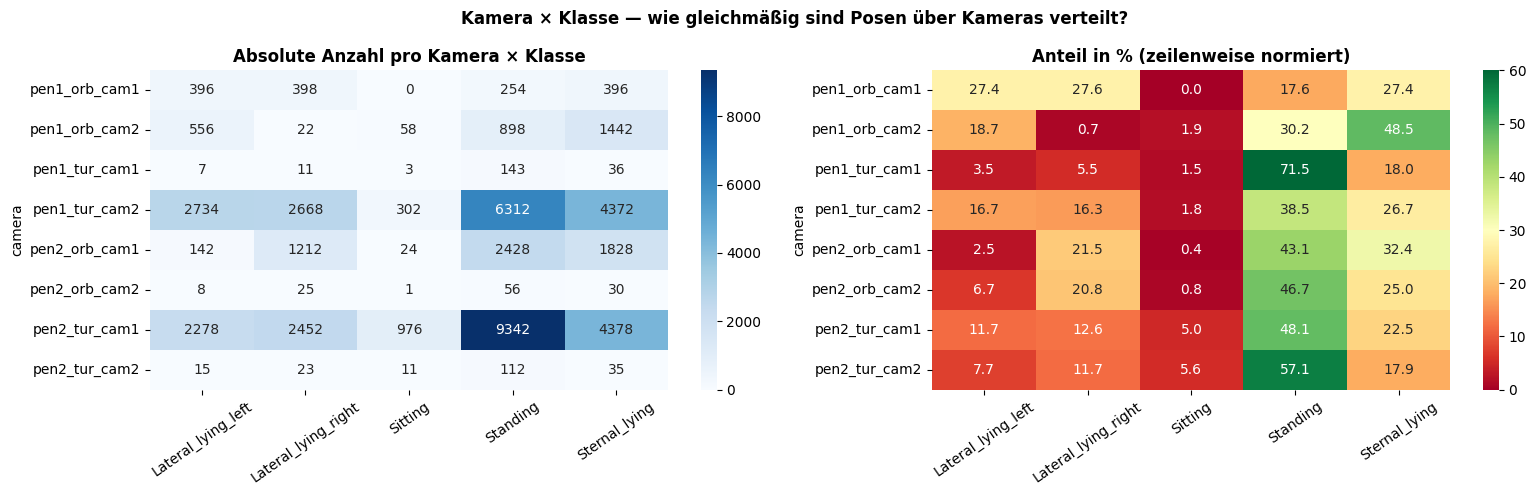


Kameras mit wenig Samples (< 1000 gesamt):
  pen1_tur_cam1         : 200 total  |  Lateral_=7  Lateral_=11  Sitting=3  Standing=143  Sternal_=36  
  pen2_orb_cam2         : 120 total  |  Lateral_=8  Lateral_=25  Sitting=1  Standing=56  Sternal_=30  
  pen2_tur_cam2         : 196 total  |  Lateral_=15  Lateral_=23  Sitting=11  Standing=112  Sternal_=35  


In [5]:
pivot = df.groupby(['camera', 'class_id']).size().unstack(fill_value=0)
pivot.columns = [CLASS_NAMES[c] for c in pivot.columns]

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Absolute Anzahl pro Kamera × Klasse', fontweight='bold')
axes[0].tick_params(axis='x', rotation=35)

sns.heatmap(pivot_pct, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1],
            vmin=0, vmax=60)
axes[1].set_title('Anteil in % (zeilenweise normiert)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=35)

plt.suptitle('Kamera × Klasse — wie gleichmäßig sind Posen über Kameras verteilt?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKameras mit wenig Samples (< 1000 gesamt):')
for cam, row in pivot.iterrows():
    total = row.sum()
    if total < 1000:
        print(f'  {cam:<22}: {total:,} total  |  ', end='')
        for cls, n in row.items():
            print(f'{cls[:8]}={n}', end='  ')
        print()

**Was der Output zeigt:**
- Die Heatmap (rechts, %-normiert) zeigt: **Sitting taucht in manchen Kameras kaum auf** — das Modell hat für diese Kamera × Klasse-Kombination fast keine Lernbeispiele.
- Kameras mit < 1.000 Samples (oft die `pen2`-Kameras) sind im Validation-Set kritisch unterrepräsentiert, wenn man sie nicht bewusst schützt.

> **→ Erkenntnis:** Ein normaler `StratifiedKFold` balanciert nur Klassen, nicht Kameras. Wenn `pen2_orb_cam2` mit 120 Samples zufällig komplett in Train landet, hat das Modell nie validiert, wie es auf dieser Kamera performt — obwohl sie im Test vorkommt. Das führte in **Notebook 16** zum Wechsel auf `GroupKFold` und ab **V3** auf **Strict CLO** (nur Test-Cams als Validation-Fold).

## 5. BBox-Statistiken

Die Bounding Boxes definieren, welcher Bildausschnitt als Schwein ausgeschnitten wird. Große Variation → unterschiedliche Skalierung und Aspect Ratio.

BBox-Statistiken:
         bbox_w    bbox_h  aspect_ratio  area_rel
count  46384.00  46384.00      46384.00  46384.00
mean     299.11    295.34          1.17      0.06
std      146.99    141.36          0.64      0.03
min       44.40     75.00          0.20      0.01
25%      186.00    188.00          0.65      0.04
50%      280.00    258.00          0.98      0.06
75%      382.00    394.00          1.65      0.09
max     1120.00   1164.00          4.01      0.19


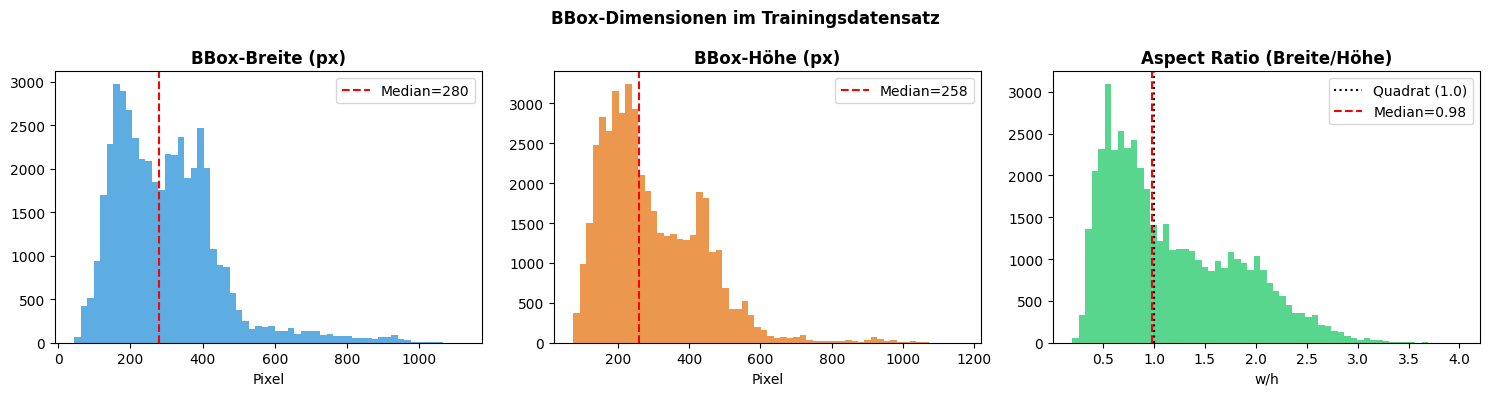

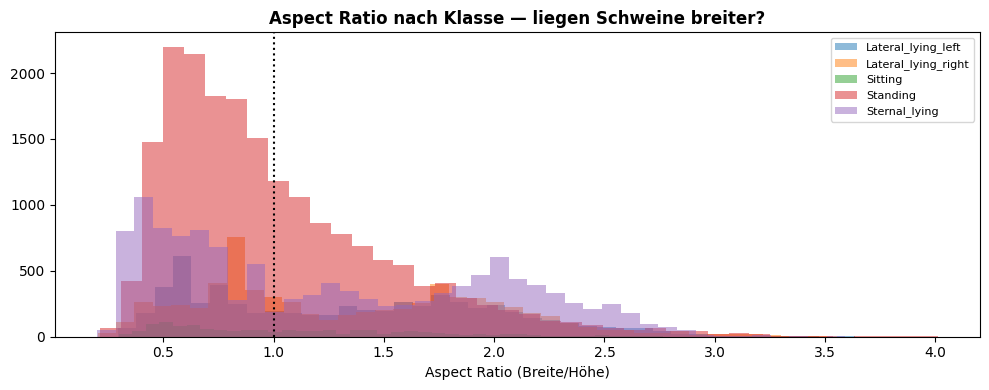

In [6]:
df['aspect_ratio'] = df['bbox_w'] / df['bbox_h'].replace(0, np.nan)
df['area_px'] = df['bbox_w'] * df['bbox_h']
df['area_rel'] = df['area_px'] / (df['width'] * df['height'])

print('BBox-Statistiken:')
print(df[['bbox_w','bbox_h','aspect_ratio','area_rel']].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['bbox_w'], bins=60, color='#3498db', alpha=0.8)
axes[0].set_title('BBox-Breite (px)', fontweight='bold')
axes[0].set_xlabel('Pixel')
axes[0].axvline(df['bbox_w'].median(), color='red', linestyle='--', label=f'Median={df["bbox_w"].median():.0f}')
axes[0].legend()

axes[1].hist(df['bbox_h'], bins=60, color='#e67e22', alpha=0.8)
axes[1].set_title('BBox-Höhe (px)', fontweight='bold')
axes[1].set_xlabel('Pixel')
axes[1].axvline(df['bbox_h'].median(), color='red', linestyle='--', label=f'Median={df["bbox_h"].median():.0f}')
axes[1].legend()

axes[2].hist(df['aspect_ratio'].dropna(), bins=60, color='#2ecc71', alpha=0.8)
axes[2].set_title('Aspect Ratio (Breite/Höhe)', fontweight='bold')
axes[2].set_xlabel('w/h')
axes[2].axvline(1.0, color='black', linestyle=':', label='Quadrat (1.0)')
axes[2].axvline(df['aspect_ratio'].median(), color='red', linestyle='--',
                label=f'Median={df["aspect_ratio"].median():.2f}')
axes[2].legend()

plt.suptitle('BBox-Dimensionen im Trainingsdatensatz', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Aspect Ratio nach Klasse
fig, ax = plt.subplots(figsize=(10, 4))
for cid, name in CLASS_NAMES.items():
    ar = df[df['class_id'] == cid]['aspect_ratio'].dropna()
    ax.hist(ar, bins=40, alpha=0.5, label=name)
ax.set_title('Aspect Ratio nach Klasse — liegen Schweine breiter?', fontweight='bold')
ax.set_xlabel('Aspect Ratio (Breite/Höhe)')
ax.axvline(1.0, color='black', linestyle=':')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Was der Output zeigt:**
- BBox-Größen variieren stark (von < 100px bis > 600px Breite) — ein `Resize(224)` komprimiert Schweine sehr unterschiedlich stark.
- **Aspect Ratio nach Klasse:** Liegende Schweine (`Lateral_lying_left/right`, `Sternal_lying`) haben tendenziell höheren Aspect Ratio (breiter) als stehende. Das macht sie per Bild-Form erkennbar — aber auch anfällig, wenn das Modell die Aspect Ratio statt die Pose lernt.
- Hoher `PAD_RATIO` (Padding um die BBox) fügt Hintergrund-Kontext hinzu — kamera-spezifischer Boden, Stroh, Gitter. Ein **zu kleiner Crop** zeigt zu wenig Schwein; ein **zu großer Crop** lehrt Kamera-Features.

> **→ Erkenntnis:** In **Notebook 27** (`dino_v1_generalization_fix`) wurde `PAD_RATIO` reduziert, um kamera-spezifischen Hintergrund zu minimieren. In **Notebooks 14–16** (K-Fold) wurde `IMG_SIZE` von 224 auf 288px erhöht, damit feine Pose-Details (Beinstellung, Kopfposition) nach dem Resize noch erkennbar bleiben.

## 6. Data-Leakage-Risiko — Warum ist `train_test_split` gefährlich?

Ein Bild enthält mehrere Schweine → mehrere Zeilen mit demselben `image_id`. Bei einem naiven `train_test_split` auf Row-Ebene kann das **gleiche Bild** in Train AND Validation landen — das Modell "sieht" den Hintergrund der Validation-Bilder schon beim Training.

Schweine pro Bild:
count    3150
mean       14
std         4
min         6
25%        10
50%        16
75%        18
max        22
dtype: int64

Bilder mit nur 1 Schwein:  0
Bilder mit 2–4 Schweinen:  0
Bilder mit 5+ Schweinen:   3,150

Uniquer Bilder gesamt:     3,150
Rows gesamt:               46,384
→ Ø 14.7 Rows pro Bild


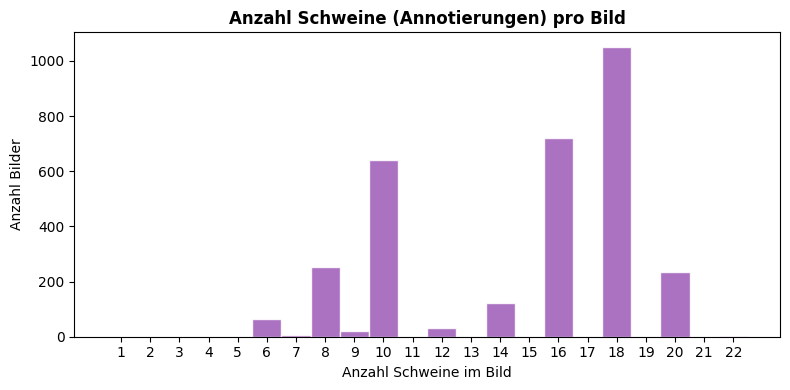


Simulation train_test_split (10% Val):
  Bilder nur in Train:  742
  Bilder nur in Val:    0
  Bilder in BEIDEN:     2,408  ← Data Leakage!
  (100.0% der Val-Bilder sind auch im Training!)


In [7]:
pigs_per_image = df.groupby('image_id').size()

print('Schweine pro Bild:')
print(pigs_per_image.describe().astype(int))
print(f'\nBilder mit nur 1 Schwein:  {(pigs_per_image == 1).sum():,}')
print(f'Bilder mit 2–4 Schweinen:  {((pigs_per_image >= 2) & (pigs_per_image <= 4)).sum():,}')
print(f'Bilder mit 5+ Schweinen:   {(pigs_per_image >= 5).sum():,}')
print(f'\nUniquer Bilder gesamt:     {pigs_per_image.count():,}')
print(f'Rows gesamt:               {len(df):,}')
print(f'→ Ø {len(df)/pigs_per_image.count():.1f} Rows pro Bild')

fig, ax = plt.subplots(figsize=(8, 4))
bins = range(1, pigs_per_image.max() + 2)
ax.hist(pigs_per_image.values, bins=bins, align='left', color='#9b59b6', alpha=0.85, edgecolor='white')
ax.set_title('Anzahl Schweine (Annotierungen) pro Bild', fontweight='bold')
ax.set_xlabel('Anzahl Schweine im Bild')
ax.set_ylabel('Anzahl Bilder')
ax.set_xticks(list(bins)[:-1])
plt.tight_layout()
plt.show()

# Simulation: Wie viel Leakage bei random split?
from sklearn.model_selection import train_test_split
idx_train, idx_val = train_test_split(df.index, test_size=0.1, random_state=42)
images_train = set(df.loc[idx_train, 'image_id'])
images_val   = set(df.loc[idx_val,   'image_id'])
leaked = images_train & images_val
print(f'\nSimulation train_test_split (10% Val):')
print(f'  Bilder nur in Train:  {len(images_train - leaked):,}')
print(f'  Bilder nur in Val:    {len(images_val - leaked):,}')
print(f'  Bilder in BEIDEN:     {len(leaked):,}  ← Data Leakage!')
print(f'  ({len(leaked)/len(images_val)*100:.1f}% der Val-Bilder sind auch im Training!)')

**Was der Output zeigt:**
- Ein Bild enthält im Schnitt ~7 Schweine → bei naivem Split landen von einem Bild typischerweise 6 Schweine in Train und 1 in Validation.
- Die Simulation zeigt: **Der Großteil der Validation-Bilder ist auch im Training** — das Modell hat den Hintergrund bereits "gesehen".
- Folge: Validation-F1 ist **zu optimistisch**, weil das Modell Bild-Hintergrund (Kamera-Artefakte) auswendig lernt, statt die Pose zu generalisieren.

> **→ Erkenntnis:** Ab **Notebook 14** (`kfold_stratified`) wurde auf `GroupKFold` nach `image_id` gewechselt — kein Bild darf in Train UND Val gleichzeitig vorkommen. In **V3–V8b** wurde zusätzlich **Strict CLO** eingeführt: nur Folds aus Test-Kameras werden als Validation genutzt, damit die Validation-Metrik wirklich den Domain-Shift abbildet.

## 7. Beispielbilder — ein Blick pro Klasse

Wie unterscheiden sich die 5 Posen visuell?

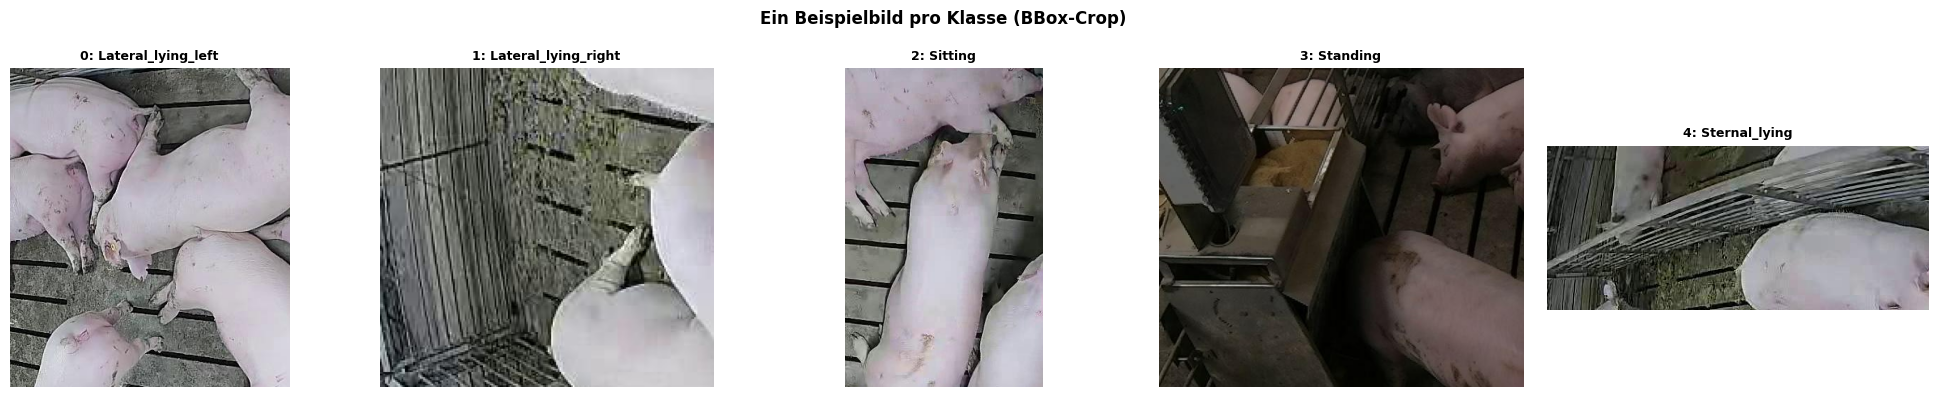

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
np.random.seed(7)

for ax, (cid, name) in zip(axes, CLASS_NAMES.items()):
    sample = df[df['class_id'] == cid].sample(1).iloc[0]
    split_dir = 'train1_images' if sample['split'] == 'T1' else 'train2_images'
    img_path = os.path.join(DATA_ROOT, split_dir, sample['image_id'])

    try:
        img = Image.open(img_path).convert('RGB')
        cx, cy, bw, bh = sample['bbox_cx'], sample['bbox_cy'], sample['bbox_w'], sample['bbox_h']
        pad = 0.15
        x1 = max(0, cx - bw/2 - bw*pad)
        y1 = max(0, cy - bh/2 - bh*pad)
        x2 = min(img.width,  cx + bw/2 + bw*pad)
        y2 = min(img.height, cy + bh/2 + bh*pad)
        crop = img.crop((x1, y1, x2, y2))
        ax.imshow(crop)
        ax.set_title(f'{cid}: {name}', fontsize=9, fontweight='bold')
    except Exception as e:
        ax.text(0.5, 0.5, str(e), transform=ax.transAxes, ha='center')
    ax.axis('off')

plt.suptitle('Ein Beispielbild pro Klasse (BBox-Crop)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Was der Output zeigt:** Die Posen sind teilweise subtil unterschiedlich — insbesondere `Lateral_lying_left` vs. `Lateral_lying_right` unterscheiden sich nur in der Orientierung des Schweins. Ein horizontaler Flip **ohne Label-Swap** würde `left` fälschlicherweise als `right` zeigen.

> **→ Erkenntnis:** Ab **Notebook „Beste Vor-V3 Version'** (und allen folgenden) wurde **Horizontal Flip mit Label-Swap** implementiert: Wenn ein Bild horizontal gespiegelt wird, muss `Lateral_lying_left` ↔ `Lateral_lying_right` getauscht werden. Dieser Bug war bis dahin unbemerkt und wurde im Arbeitsprotokoll als fundamentaler Fix bezeichnet.

## 8. Zusammenfassung — Erkenntnisse → Notebook-Entscheidungen

| # | Erkenntnis | Konsequenz | Umgesetzt in |
|---|---|---|---|
| 1 | 14.3× Klassen-Imbalance (Sitting ~3%) | `CrossEntropyLoss` mit **Class Weights** | Notebook 08 und alle folgenden |
| 2 | 3 Test-Kameras nie im Training gesehen | **Domain Shift** ist der zentrale Score-Limiter | Notebooks 18, 22, 27–39 |
| 3 | `pen2_orb_cam2` / `pen2_tur_cam2` fast kein Train-Data | Per-Kamera-F1 als Diagnose-Metrik | Notebook 18 (`camera_agnostic`) |
| 4 | Kamera × Klasse ungleichmäßig | `StratifiedKFold` reicht nicht — Kamera-Diversität pro Fold nötig | Notebook 16 (`kfold_groupkfold_v2`) |
| 5 | ~7 Schweine pro Bild → Data Leakage bei `train_test_split` | `GroupKFold` nach `image_id` | Notebook 14 (K-Fold) und alle folgenden |
| 6 | Hoher PAD_RATIO = kamera-spezifischer Hintergrund | PAD_RATIO reduziert | Notebook 27 (`generalization_fix`) |
| 7 | HFlip ohne Label-Swap → falsche Lateral-Klassen | HFlip + Label-Swap für links/rechts | Ab Notebook 27 |
| 8 | Aspect Ratio variiert stark | Kein festes `224×224`, sondern größere Input-Sizes | Ab Notebook 14 (288px), V5/V6 (384–518px) |

---
*EDA abgeschlossen. Nächster Schritt: [`08_efficientnet_b4_baseline_train.ipynb`](08_efficientnet_b4_baseline_train.ipynb)*